In [1]:
import os
import torch
import numpy as np
import random

def seed_everything(seed):
    """
    Set random seed for reproducibility
    """
    # 1. Python & Numpy
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    
    # 2. PyTorch (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"🔒 Locked Random Seed: {seed}")


In [2]:



def seed_everything_random():
    """
    Tạo random seed, set seed đó, và return seed để bạn biết
    """
    # Tạo random seed
    random_seed = random.randint(0, 999999)
    
    # Set seed
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)
    np.random.seed(random_seed)
    random.seed(random_seed)
    
    # Để reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    return random_seed


In [3]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
#load data
df_men =pd.read_csv(r"/home/ducm/RERUM/dataset/Hillstrom-Men.csv")
df_men = df_men.drop(columns="Unnamed: 0")
print ("---------------------------")
print ("null count:")
print (df_men.isnull().sum())
print ("---------------------------")
print(df_men.dtypes)
print ("---------------------------")
print ("labels:")
print(df_men.columns.tolist())
print ("---------------------------")
print("data shape:")
print(df_men.shape)


---------------------------
null count:
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
visit              0
conversion         0
spend              0
treatment          0
dtype: int64
---------------------------
recency              int64
history_segment      int64
history            float64
mens                 int64
womens               int64
zip_code            object
newbie               int64
channel             object
visit                int64
conversion           int64
spend              float64
treatment            int64
dtype: object
---------------------------
labels:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'visit', 'conversion', 'spend', 'treatment']
---------------------------
data shape:
(42613, 12)


In [5]:
#Hillstrom-men
#split num and cate
cate_cols = ['zip_code', 'channel']
num_cols = ['recency', 'history_segment', 'history']
#split x y t
y_men = df_men["spend"]
t_men = df_men["treatment"]
x_men = df_men.drop(columns=["spend", "treatment", "visit", "conversion"])

# x_men_encode = pd.get_dummies(x_men, columns=cate_cols, drop_first=True)
# x_men_encode = x_men_encode.astype(float)

#train test split - stratify CHỈ bằng treatment
x_men_train, x_men_test, t_men_train, t_men_test, y_men_train, y_men_test = train_test_split(
    x_men, t_men.values, y_men.values,
    test_size=0.3, random_state=42, stratify= t_men
)

# Tạo stratify cho val split - chỉ dùng treatment
stratify_var_train = pd.Series(t_men_train)

x_men_train, x_men_val, t_men_train, t_men_val, y_men_train, y_men_val = train_test_split(
    x_men_train, t_men_train, y_men_train,
    test_size=(1/7), random_state=42, stratify= t_men_train
)

# Fit get_dummies trên train, sau đó align với val/test
x_men_train_encode = pd.get_dummies(x_men_train, columns=cate_cols, drop_first=True)
x_men_val_encode = pd.get_dummies(x_men_val, columns=cate_cols, drop_first=True)
x_men_test_encode = pd.get_dummies(x_men_test, columns=cate_cols, drop_first=True)

# Align columns
x_men_val_encode = x_men_val_encode.reindex(columns=x_men_train_encode.columns, fill_value=0)
x_men_test_encode = x_men_test_encode.reindex(columns=x_men_train_encode.columns, fill_value=0)

scaler = StandardScaler()
x_men_train= scaler.fit_transform(x_men_train_encode)
x_men_val = scaler.transform(x_men_val_encode)
x_men_test = scaler.transform(x_men_test_encode)

print ("✅ Train/Val/Test split with stratification ONLY by treatment (NO DATA LEAKAGE)")
print (f"Train: {x_men_train.shape}, Val: {x_men_val.shape}, Test: {x_men_test.shape}")
print (f"Treatment distribution - Train: {np.mean(t_men_train):.2%}, Val: {np.mean(t_men_val):.2%}, Test: {np.mean(t_men_test):.2%}")
print (f"Spend mean - Train: {np.mean(y_men_train):.2f}, Val: {np.mean(y_men_val):.2f}, Test: {np.mean(y_men_test):.2f}")

# x_men = pd.DataFrame(x_men_train)
x_men_train

✅ Train/Val/Test split with stratification ONLY by treatment (NO DATA LEAKAGE)
Train: (25567, 10), Val: (4262, 10), Test: (12784, 10)
Treatment distribution - Train: 50.00%, Val: 50.00%, Test: 50.00%
Spend mean - Train: 1.00, Val: 0.95, Test: 1.14


array([[-1.36323828, -0.95770591, -0.65534372, ...,  1.22273126,
        -0.87900784,  1.12185957],
       [ 0.63260109, -0.30863193, -0.31367375, ...,  1.22273126,
        -0.87900784,  1.12185957],
       [ 0.34748118, -0.30863193, -0.4344948 , ...,  1.22273126,
         1.13764628, -0.89137716],
       ...,
       [ 0.34748118,  0.34044206,  0.30319097, ..., -0.8178412 ,
        -0.87900784,  1.12185957],
       [-1.07811837,  0.34044206,  0.16319135, ..., -0.8178412 ,
         1.13764628, -0.89137716],
       [-0.79299846, -0.95770591, -0.61911315, ..., -0.8178412 ,
        -0.87900784,  1.12185957]], shape=(25567, 10))

In [6]:
#Transform to tensor
def to_tensor(df):
    return torch.tensor(df, dtype=torch.float32)

x_men_train_t = to_tensor(x_men_train)
x_men_val_t = to_tensor(x_men_val)
x_men_test_t = to_tensor(x_men_test)

y_men_train_t = to_tensor(y_men_train).unsqueeze(1)
y_men_val_t = to_tensor(y_men_val).unsqueeze(1)
y_men_test_t = to_tensor(y_men_test).unsqueeze(1)

t_men_train_t = to_tensor(t_men_train.astype(float)).unsqueeze(1)
t_men_val_t = to_tensor(t_men_val.astype(float)).unsqueeze(1)
t_men_test_t = to_tensor(t_men_test.astype(float)).unsqueeze(1)

# sampler = get_sampler(y_men_train_t, target_positive_ratio=0.2)

#Data loader
train_dataset = TensorDataset(x_men_train_t, t_men_train_t, y_men_train_t)
val_dataset = TensorDataset(x_men_val_t, t_men_val_t, y_men_val_t)
test_dataset = TensorDataset(x_men_test_t, t_men_test_t, y_men_test_t)

batch_size = 800
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print ("-------------------------------------------------------------")
print ("✅Completed tranform to tensor✅")
print (f"Shape of train: x={x_men_train_t.shape}; y ={y_men_train_t.shape}; t={t_men_train_t.shape}")
print (f"Shape of val: x={x_men_val_t.shape}; y={y_men_val_t.shape}; t={t_men_val_t.shape}")
print (f"Shape of test: x={x_men_test_t.shape}; y={y_men_test_t.shape}; t={t_men_test_t.shape}")

-------------------------------------------------------------
✅Completed tranform to tensor✅
Shape of train: x=torch.Size([25567, 10]); y =torch.Size([25567, 1]); t=torch.Size([25567, 1])
Shape of val: x=torch.Size([4262, 10]); y=torch.Size([4262, 1]); t=torch.Size([4262, 1])
Shape of test: x=torch.Size([12784, 10]); y=torch.Size([12784, 1]); t=torch.Size([12784, 1])


Evaluation metrics

In [7]:
from metrics import auuc, auqc, lift, krcc

Build Model

In [8]:
from dragonnet import Dragonnet

In [9]:
print("📊 Data Distribution Check:")
print(f"Y train: mean={y_men_train.mean():.4f}, std={y_men_train.std():.4f}")
print(f"Y train zeros: {(y_men_train == 0).sum()} / {len(y_men_train)} ({(y_men_train == 0).sum()/len(y_men_train)*100:.1f}%)")
print(f"\nTreatment balance:")
print(f"  Train: {(t_men_train == 1).sum()} treated, {(t_men_train == 0).sum()} control")
print(f"  Test:  {(t_men_test == 1).sum()} treated, {(t_men_test == 0).sum()} control")

📊 Data Distribution Check:
Y train: mean=1.0015, std=14.5993
Y train zeros: 25338 / 25567 (99.1%)

Treatment balance:
  Train: 12784 treated, 12783 control
  Test:  6392 treated, 6392 control


In [10]:
epochs = 300
alpha = 1
beta = 1
lr = 5e-4
wd = 1e-4
early_stop_metric = "loss"
ema = True
ema_alpha = 0.05
patience = 30
shared_dropout = 0
outcome_droupout = 0 
shared_hidden = 200
outcome_hidden = 100
uplift_lambda = 100
response_lambda = 0
early_stop_start = 0
ranking_start = 5

print (f" epochs = {epochs}")
print (f" alpha = {alpha}")
print (f" beta = {beta}")
print (f" learning rate = {lr}")
print (f" weight decay = {wd}")
print (f" early stop = {early_stop_metric}")
print (f" use ema = {ema}")
print (f" ema alpha = {ema_alpha}")
print (f" patience = {patience}")
print (f" share dropout = {shared_dropout}")
print (f" outcome dropout = {outcome_droupout}")
print (f" shared hidden = {shared_hidden}")
print (f" outcome hidden = {outcome_hidden}")

 epochs = 300
 alpha = 1
 beta = 1
 learning rate = 0.0005
 weight decay = 0.0001
 early stop = loss
 use ema = True
 ema alpha = 0.05
 patience = 30
 share dropout = 0
 outcome dropout = 0
 shared hidden = 200
 outcome hidden = 100


🔒 Locked Random Seed: 412312


🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 300 epochs, select model with lowest validation loss
   Patience: 30 epochs
Epoch 1/300 | Base Loss: 77.9710 | Tarreg Loss: 38.637100 | Uplift Loss: 0.000000 | Total Loss: 116.6081 | Val Loss: 378.0434 | Val Qini: -0.0129 ⭐ NEW BEST (lowest loss)
Epoch 2/300 | Base Loss: 157.0577 | Tarreg Loss: 79.014725 | Uplift Loss: 0.000000 | Total Loss: 236.0724 | Val Loss: 378.2627 | Val Qini: -0.1323 (patience: 1/30)
Epoch 3/300 | Base Loss: 48.1524 | Tarreg Loss: 23.534943 | Uplift Loss: 0.000000 | Total Loss: 71.6873 | Val Loss: 378.5482 | Val Qini: -0.5836 (patience: 2/30)
Epoch 4/300 | Base Loss: 137.3238 | Tarreg Loss: 68.699028 | Uplift Loss: 0.000000 | Total Loss: 206.0229 | Val Loss: 377.5955 | Val Qini: -0.5243 ⭐ NEW BEST (lowest loss)
Epoch 5/300 | Base Loss: 551.5104 | Tarreg Loss: 281.372803 | Uplift Loss: 0.000000 | Total Loss: 832.8832 | Val Loss: 377.5708 | Val Qini: -0.8233 

/home/ducm/RERUM/dragonnet + UR/dragonnet.py:391: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


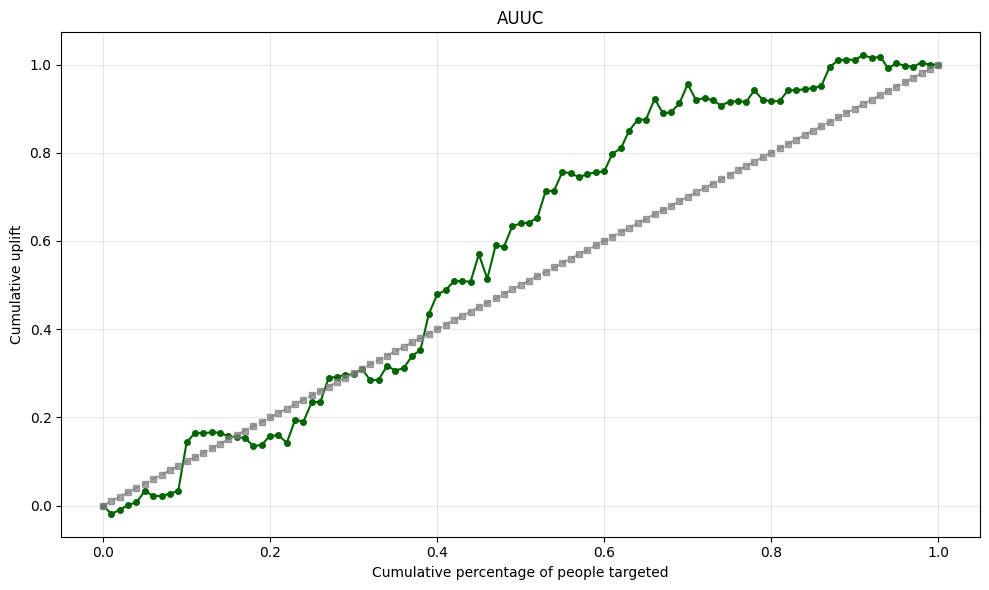

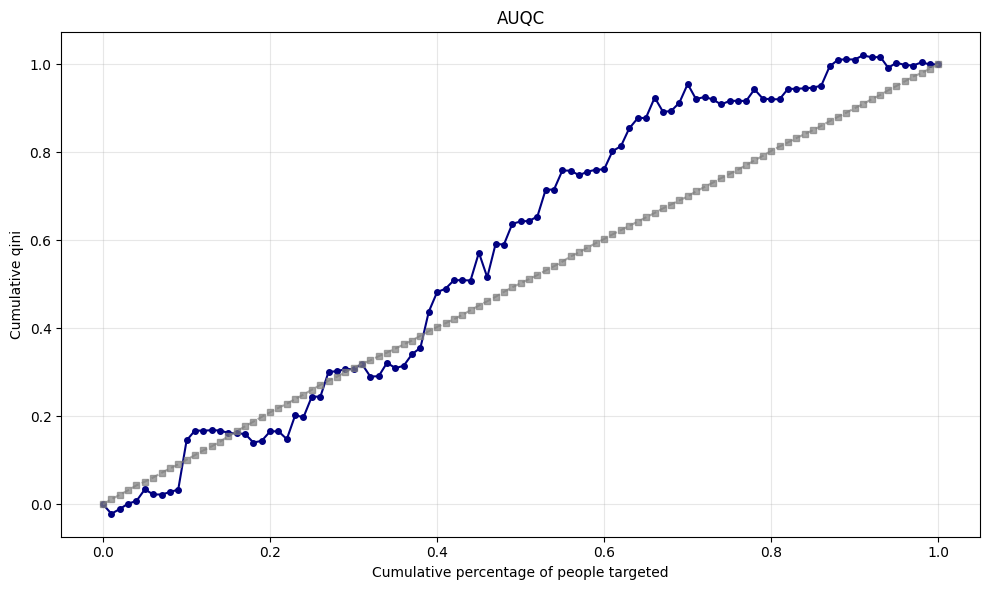

----------------------------------------
AUUC: 0.575
AUQC: 0.578
Lift: 1.017
KRCC: 0.068
seed: 412312


In [11]:
seed = 412312
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      uplift_ranking=uplift_lambda,
                      response_ranking= response_lambda,
                      early_stop_start_epoch=early_stop_start,
                      ranking_start_epoch= ranking_start
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")

print ("Evaluating baseline🔃🔃🔃")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_men_test_t_on_device = x_men_test_t.to(device)

y0_pred, y1_pred, _,_ = dragonnet.predict(x_men_test_t_on_device)

# Move predicted tensors back to CPU before converting to numpy arrays
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()

y_true = y_men_test_t.cpu().numpy().flatten() # Ensure true labels are also on CPU if they were ever moved
t_true = t_men_test_t.cpu().numpy().flatten() # Ensure true treatments are also on CPU if they were ever moved

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins= 100)

print ("-"*40)
print (f"AUUC: {auuc_score:.3f}")
print (f"AUQC: {auqc_score:.3f}")
print (f"Lift: {lift_score:.3f}")
print (f"KRCC: {krcc_score:.3f}")
print (f"seed: {seed}")

🔒 Locked Random Seed: 42
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 300 epochs, select model with lowest validation loss
   Patience: 30 epochs
Epoch 1/300 | Base Loss: 724.5204 | Tarreg Loss: 372.705231 | Uplift Loss: 0.000000 | Total Loss: 1097.2256 | Val Loss: 376.7886 | Val Qini: -0.8518 ⭐ NEW BEST (lowest loss)
Epoch 2/300 | Base Loss: 249.5983 | Tarreg Loss: 124.506783 | Uplift Loss: 0.000000 | Total Loss: 374.1051 | Val Loss: 376.4789 | Val Qini: -0.5498 ⭐ NEW BEST (lowest loss)
Epoch 3/300 | Base Loss: 90.7845 | Tarreg Loss: 45.884987 | Uplift Loss: 0.000000 | Total Loss: 136.6695 | Val Loss: 376.6828 | Val Qini: -0.7389 (patience: 1/30)
Epoch 4/300 | Base Loss: 49.7392 | Tarreg Loss: 24.567389 | Uplift Loss: 0.000000 | Total Loss: 74.3066 | Val Loss: 376.7167 | Val Qini: -0.5240 (patience: 2/30)
Epoch 5/300 | Base Loss: 164.9684 | Tarreg Loss: 86.409019 | Uplift Loss: 0.000000 | Total Loss: 251.3774 | Val Loss: 37

Exception ignored in: <function _releaseLock at 0x77698e0ed870>
Traceback (most recent call last):
  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/logging/__init__.py", line 228, in _releaseLock
    def _releaseLock():
KeyboardInterrupt: 


Epoch 12/300 | Base Loss: 96.5305 | Tarreg Loss: 47.516884 | Uplift Loss: 3.041744 | Total Loss: 448.2218 | Val Loss: 398.2839 | Val Qini: -0.9360 (patience: 5/30)
Epoch 13/300 | Base Loss: 76.4734 | Tarreg Loss: 38.467209 | Uplift Loss: 0.898899 | Total Loss: 204.8305 | Val Loss: 399.4289 | Val Qini: -0.6987 (patience: 6/30)
Epoch 14/300 | Base Loss: 577.3831 | Tarreg Loss: 290.583954 | Uplift Loss: 4.423607 | Total Loss: 1310.3278 | Val Loss: 424.1921 | Val Qini: -0.8110 (patience: 7/30)
Epoch 15/300 | Base Loss: 287.6469 | Tarreg Loss: 142.457703 | Uplift Loss: -3.528554 | Total Loss: 77.2492 | Val Loss: 449.4589 | Val Qini: -0.4751 (patience: 8/30)
Epoch 16/300 | Base Loss: 124.7097 | Tarreg Loss: 59.198463 | Uplift Loss: 13.246299 | Total Loss: 1508.5380 | Val Loss: 428.3788 | Val Qini: -0.6176 (patience: 9/30)
Epoch 17/300 | Base Loss: 560.0517 | Tarreg Loss: 279.803162 | Uplift Loss: -13.694651 | Total Loss: -529.6102 | Val Loss: 535.1964 | Val Qini: -0.2600 (patience: 10/30)
Ep

/home/ducm/RERUM/dragonnet + UR/dragonnet.py:391: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


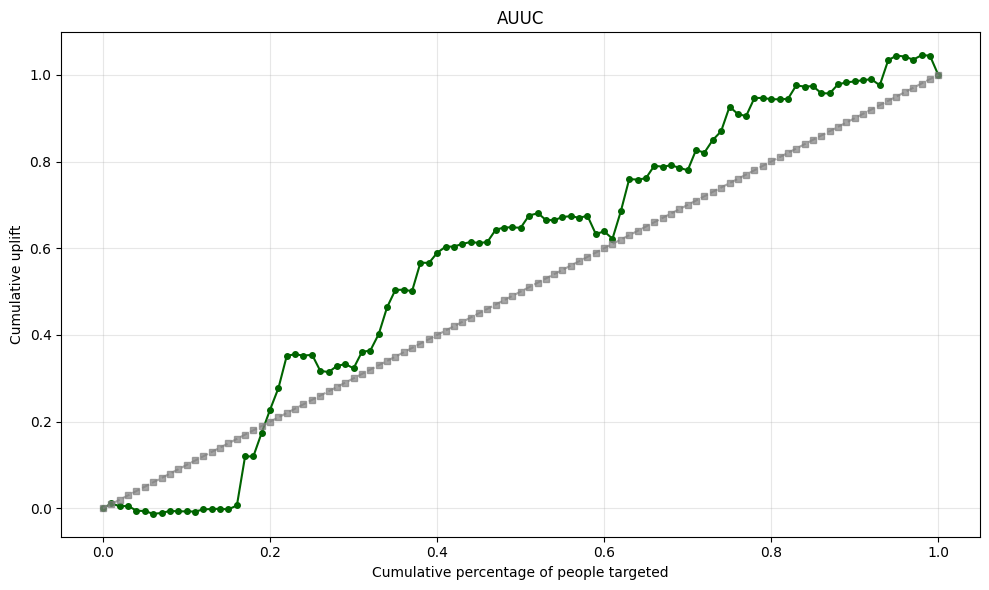

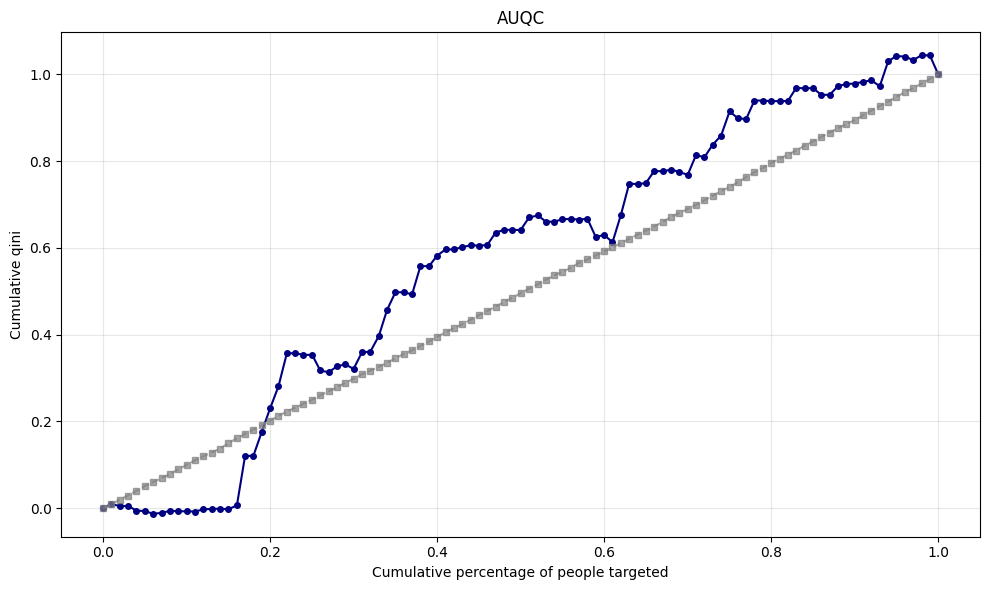

----------------------------------------
AUUC: 0.575
AUQC: 0.570
Lift: 1.105
KRCC: 0.039
seed: 42


In [12]:
seed = 42
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      uplift_ranking=uplift_lambda,
                      response_ranking= response_lambda,
                      early_stop_start_epoch=early_stop_start,
                      ranking_start_epoch= ranking_start
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")

print ("Evaluating baseline🔃🔃🔃")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_men_test_t_on_device = x_men_test_t.to(device)

y0_pred, y1_pred, _,_ = dragonnet.predict(x_men_test_t_on_device)

# Move predicted tensors back to CPU before converting to numpy arrays
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()

y_true = y_men_test_t.cpu().numpy().flatten() # Ensure true labels are also on CPU if they were ever moved
t_true = t_men_test_t.cpu().numpy().flatten() # Ensure true treatments are also on CPU if they were ever moved

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins= 100)

print ("-"*40)
print (f"AUUC: {auuc_score:.3f}")
print (f"AUQC: {auqc_score:.3f}")
print (f"Lift: {lift_score:.3f}")
print (f"KRCC: {krcc_score:.3f}")
print (f"seed: {seed}")

In [ ]:
seed = 1874
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      uplift_ranking=uplift_lambda,
                      response_ranking= response_lambda,
                      early_stop_start_epoch=early_stop_start,
                      ranking_start_epoch= ranking_start
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")

print ("Evaluating baseline🔃🔃🔃")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_men_test_t_on_device = x_men_test_t.to(device)

y0_pred, y1_pred, _,_ = dragonnet.predict(x_men_test_t_on_device)

# Move predicted tensors back to CPU before converting to numpy arrays
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()

y_true = y_men_test_t.cpu().numpy().flatten() # Ensure true labels are also on CPU if they were ever moved
t_true = t_men_test_t.cpu().numpy().flatten() # Ensure true treatments are also on CPU if they were ever moved

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins= 100)

print ("-"*40)
print (f"AUUC: {auuc_score:.3f}")
print (f"AUQC: {auqc_score:.3f}")
print (f"Lift: {lift_score:.3f}")
print (f"KRCC: {krcc_score:.3f}")
print (f"seed: {seed}")

🔒 Locked Random Seed: 1874
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 300 epochs, select model with lowest validation loss
   Patience: 30 epochs


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x77a932ddbd00>Exception ignored in: 
Traceback (most recent call last):
  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x77a932ddbd00>
    Traceback (most recent call last):
self._shutdown_workers()  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__

  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    self._shutdown_workers()    
if w.is_alive():  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    if w.is_alive():    
assert self._parent_pid == os.getp

Epoch 1/300 | Base Loss: 1458.7056 | Tarreg Loss: 755.616821 | Uplift Loss: 0.000000 | Total Loss: 2214.3223 | Val Loss: 381.9094 | Val Qini: -1.4915 ⭐ NEW BEST (lowest loss)


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x77a932ddbd00>
Traceback (most recent call last):
  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Exception ignored in:     if w.is_alive():<function _MultiProcessingDataLoaderIter.__del__ at 0x77a932ddbd00>

Traceback (most recent call last):
  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()assert self._parent_pid == os.getpid(), 'can only test a child process'
  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1690, in _s

Epoch 2/300 | Base Loss: 448.0667 | Tarreg Loss: 223.845230 | Uplift Loss: 0.000000 | Total Loss: 671.9119 | Val Loss: 379.8224 | Val Qini: -0.8358 ⭐ NEW BEST (lowest loss)


...

Epoch 14/300 | Base Loss: 339.7691 | Tarreg Loss: 166.528839 | Uplift Loss: 0.000000 | Total Loss: 506.2979 | Val Loss: 379.4716 | Val Qini: -0.6287 (patience: 3/30)


Exception ignored in: Exception ignored in: <function WeakSet.__init__.<locals>._remove at 0x77a9881497e0><function WeakSet.__init__.<locals>._remove at 0x77a9881497e0>

KeyboardInterrupt: 



Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/_weakrefset.py", line 39, in _remove
  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/_weakrefset.py", line 39, in _remove
        def _remove(item, selfref=ref(self)):def _remove(item, selfref=ref(self)):

KeyboardInterruptKeyboardInterrupt: : 

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x77a932ddbd00>Exception ignored in: 


<function _MultiProcessingDataLoaderIter.__del__ at 0x77a932ddbd00>Traceback (most recent call last):

  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Traceback (most recent call last):
  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()    
self._shutdown_workers()  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():    
if w.is_alive():  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/multiprocessing/process.py", line 160, in is_alive

      File "/home/ducm/miniconda3/envs/dl/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
assert self._parent_pid == os.getpid(), 'c

🔒 Locked Random Seed: 902745
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 300 epochs, select model with lowest validation loss
   Patience: 30 epochs
Epoch 1/300 | Base Loss: 699.6998 | Tarreg Loss: 347.992645 | Uplift Loss: 0.000000 | Total Loss: 1047.6924 | Val Loss: 378.6207 | Val Qini: -1.0322 ⭐ NEW BEST (lowest loss)
Epoch 2/300 | Base Loss: 681.8480 | Tarreg Loss: 358.519806 | Uplift Loss: 0.000000 | Total Loss: 1040.3678 | Val Loss: 378.1954 | Val Qini: -0.6858 ⭐ NEW BEST (lowest loss)
Epoch 3/300 | Base Loss: 361.6530 | Tarreg Loss: 178.390930 | Uplift Loss: 0.000000 | Total Loss: 540.0439 | Val Loss: 379.3603 | Val Qini: -0.6657 (patience: 1/30)
Epoch 4/300 | Base Loss: 1249.4928 | Tarreg Loss: 626.489136 | Uplift Loss: 0.000000 | Total Loss: 1875.9819 | Val Loss: 378.7705 | Val Qini: -0.7005 (patience: 2/30)
Epoch 5/300 | Base Loss: 532.6890 | Tarreg Loss: 262.899689 | Uplift Loss: 0.000000 | Total Loss: 795.5886 |

/home/ducm/RERUM/dragonnet + UR/dragonnet.py:391: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


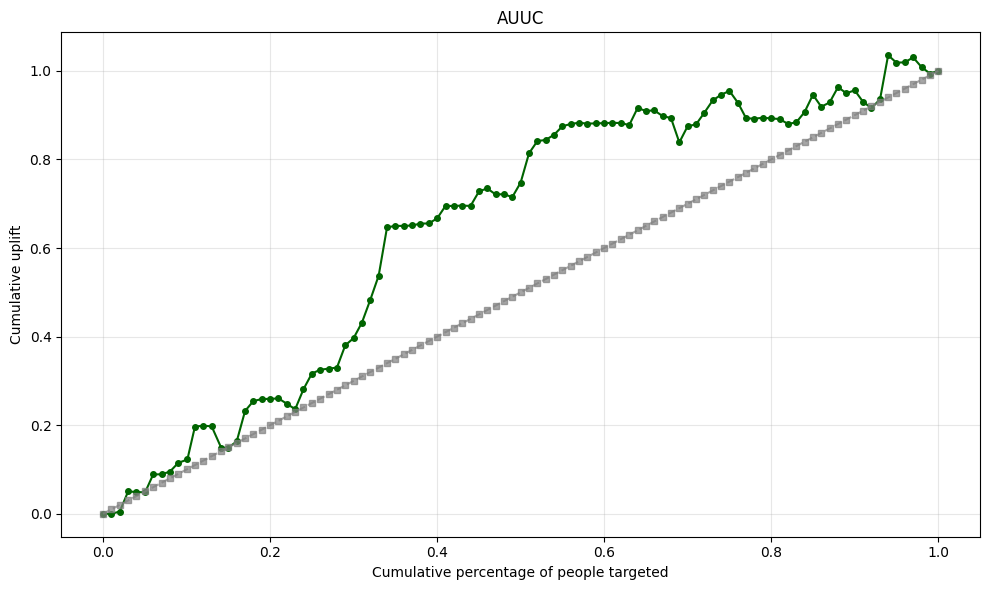

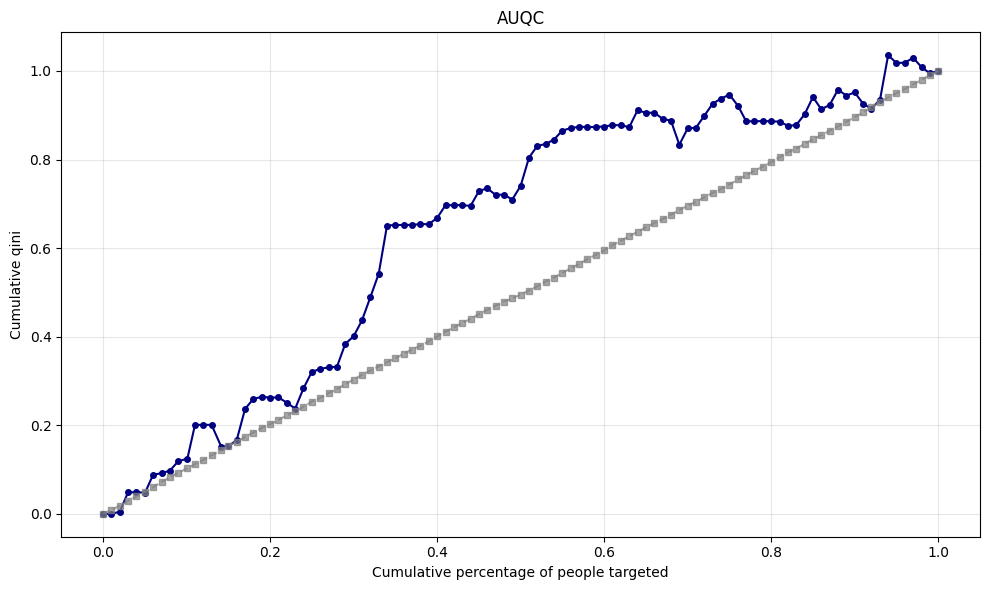

----------------------------------------
AUUC: 0.643
AUQC: 0.641
Lift: 1.356
KRCC: 0.157
seed: 902745


In [ ]:
seed = 902745
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      uplift_ranking=uplift_lambda,
                      response_ranking= response_lambda,
                      early_stop_start_epoch=early_stop_start,
                      ranking_start_epoch= ranking_start

)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")

print ("Evaluating baseline🔃🔃🔃")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_men_test_t_on_device = x_men_test_t.to(device)

y0_pred, y1_pred, _,_ = dragonnet.predict(x_men_test_t_on_device)

# Move predicted tensors back to CPU before converting to numpy arrays
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()

y_true = y_men_test_t.cpu().numpy().flatten() # Ensure true labels are also on CPU if they were ever moved
t_true = t_men_test_t.cpu().numpy().flatten() # Ensure true treatments are also on CPU if they were ever moved

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins= 100)

print ("-"*40)
print (f"AUUC: {auuc_score:.3f}")
print (f"AUQC: {auqc_score:.3f}")
print (f"Lift: {lift_score:.3f}")
print (f"KRCC: {krcc_score:.3f}")
print (f"seed: {seed}")     

🔒 Locked Random Seed: 1
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 300 epochs, select model with lowest validation loss
   Patience: 30 epochs
Epoch 1/300 | Base Loss: 1013.7250 | Tarreg Loss: 515.564331 | Uplift Loss: 0.000000 | Total Loss: 1529.2893 | Val Loss: 377.7282 | Val Qini: -0.8578 ⭐ NEW BEST (lowest loss)
Epoch 2/300 | Base Loss: 427.3751 | Tarreg Loss: 215.576065 | Uplift Loss: 0.000000 | Total Loss: 642.9512 | Val Loss: 377.2855 | Val Qini: -0.1574 ⭐ NEW BEST (lowest loss)
Epoch 3/300 | Base Loss: 532.6095 | Tarreg Loss: 264.746826 | Uplift Loss: 0.000000 | Total Loss: 797.3563 | Val Loss: 377.2780 | Val Qini: -0.5619 ⭐ NEW BEST (lowest loss)
Epoch 4/300 | Base Loss: 1192.5890 | Tarreg Loss: 574.654053 | Uplift Loss: 0.000000 | Total Loss: 1767.2430 | Val Loss: 377.0645 | Val Qini: -0.2647 ⭐ NEW BEST (lowest loss)
Epoch 5/300 | Base Loss: 859.4750 | Tarreg Loss: 424.677582 | Uplift Loss: 0.000000 | Total Loss:

/home/ducm/RERUM/dragonnet + UR/dragonnet.py:391: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


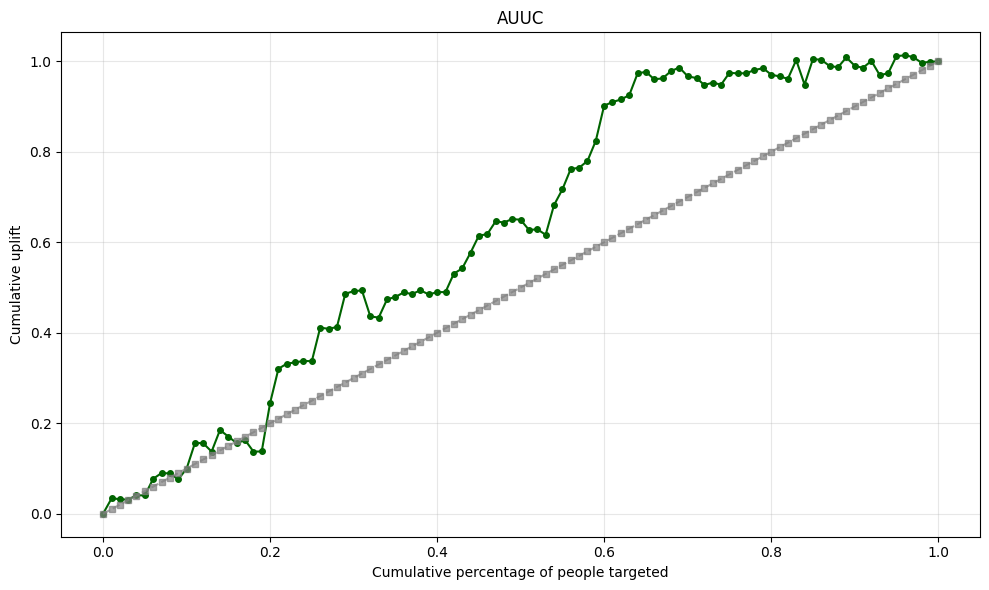

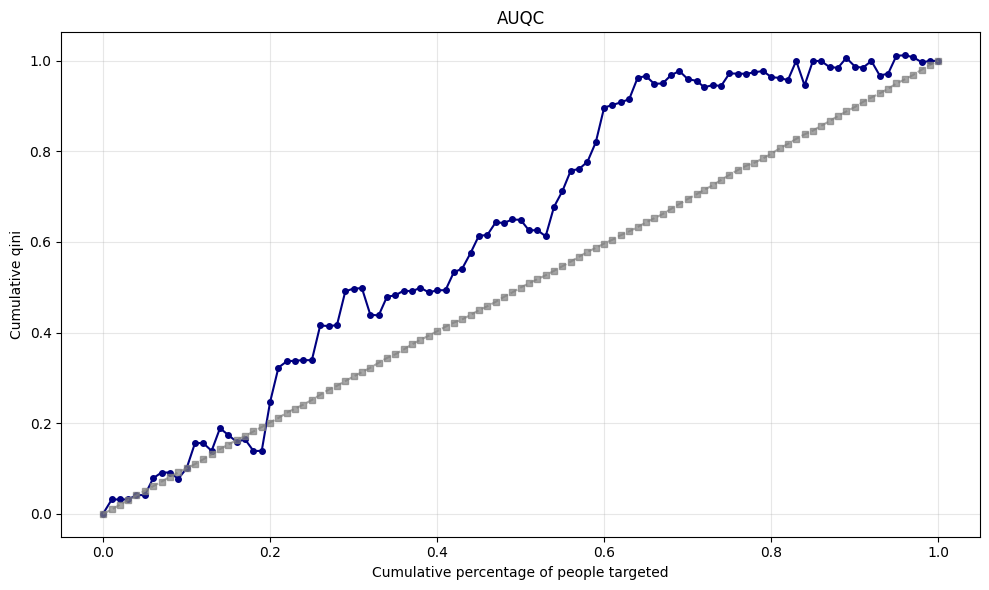

----------------------------------------
AUUC: 0.627
AUQC: 0.626
Lift: 1.682
KRCC: 0.086
seed: 1


In [ ]:
seed = 1
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      uplift_ranking=uplift_lambda,
                      response_ranking= response_lambda,
                      early_stop_start_epoch=early_stop_start,
                      ranking_start_epoch= ranking_start

)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")

print ("Evaluating baseline🔃🔃🔃")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_men_test_t_on_device = x_men_test_t.to(device)

y0_pred, y1_pred, _,_ = dragonnet.predict(x_men_test_t_on_device)

# Move predicted tensors back to CPU before converting to numpy arrays
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()

y_true = y_men_test_t.cpu().numpy().flatten() # Ensure true labels are also on CPU if they were ever moved
t_true = t_men_test_t.cpu().numpy().flatten() # Ensure true treatments are also on CPU if they were ever moved

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins= 100)

print ("-"*40)
print (f"AUUC: {auuc_score:.3f}")
print (f"AUQC: {auqc_score:.3f}")
print (f"Lift: {lift_score:.3f}")
print (f"KRCC: {krcc_score:.3f}")
print (f"seed: {seed}")